# Euclidean distance, global shifts and DTW — 2026-09-24

Fresh extraction with current pyspi. Each point below represents one simulated multivariate time series; channel pairs within it are not independent replicates.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
while not (ROOT / 'src').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from scripts.refresh_case_figures import (analyze, plot_rainclouds, plot_mi_sensitivity, plot_spi_planes, plot_dtw_sweep)
DATA = ROOT / 'data/cases/dtw-euclidean-260924/data'
OUT = ROOT / 'results/cases/dtw-euclidean-260924'
# Analyse existing MPI archives; this never reruns pyspi.
frame = analyze(DATA, 'dtw', OUT)
audit = json.loads((OUT / 'audit.json').read_text())
print(f"{audit['datasets']} datasets; {len(audit['spis'])} focused SPIs; {audit['nonfinite_off_diagonal_values']} nonfinite off-diagonal values")

350 datasets; 3 focused SPIs; 0 nonfinite off-diagonal values


Each channel is a noisy copy of an AR(1) mother ($a=0.5$), with a fixed lag and independent rebound warping. We retain $M=20$, $T=1000$, 50 instances/condition, lag range 0–5, fixed excursion size 3, noise base 0.1 and uniform multiplier range $[1/2.718,2.718]$. The first control has neither lag nor warping; the second has lag only.

All distances use the same squared-error cost and division by $\sqrt{T}$. The shifted distance minimises over shifts −10 through 10, including boundary costs; unrestricted DTW searches a larger set of admissible paths. Therefore DTW ≤ shifted ≤ Euclidean is a structural property, not evidence that DTW recovered the physical warp. The divisor is the record length, **not warping-path length**.

Lines show mean SPI–SPI Pearson agreement; bars are pointwise 95% Student-t intervals over the 50 independent MTS instances. The first control is separated because it has a different lag range.

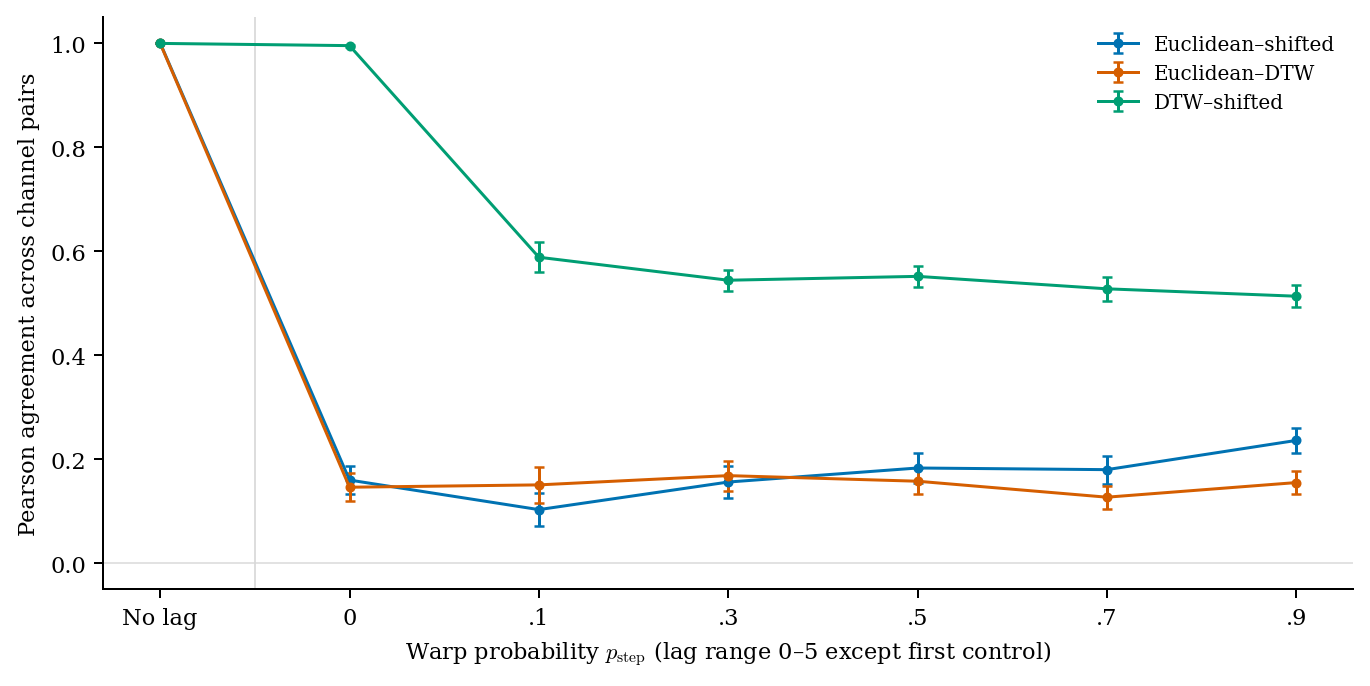

In [2]:
fig = plot_dtw_sweep(frame, OUT)
plt.show()

Lag alone separates Euclidean distance from both alignment-aware distances, while DTW–shifted agreement remains 0.995 on average. Warping reduces the latter to 0.51–0.59; it does not produce a strictly monotonic decline at every step. No distance-hierarchy violations occur among the 66,500 unique channel pairs across the 350 datasets.

Predetermined instance 0 illustrates no lag/no warp, lag only, and heavy warping. Colour shows the absolute generating lag difference. Dashed lines mark equal distances. Each panel uses matching x/y scales, with limits varying between panels.

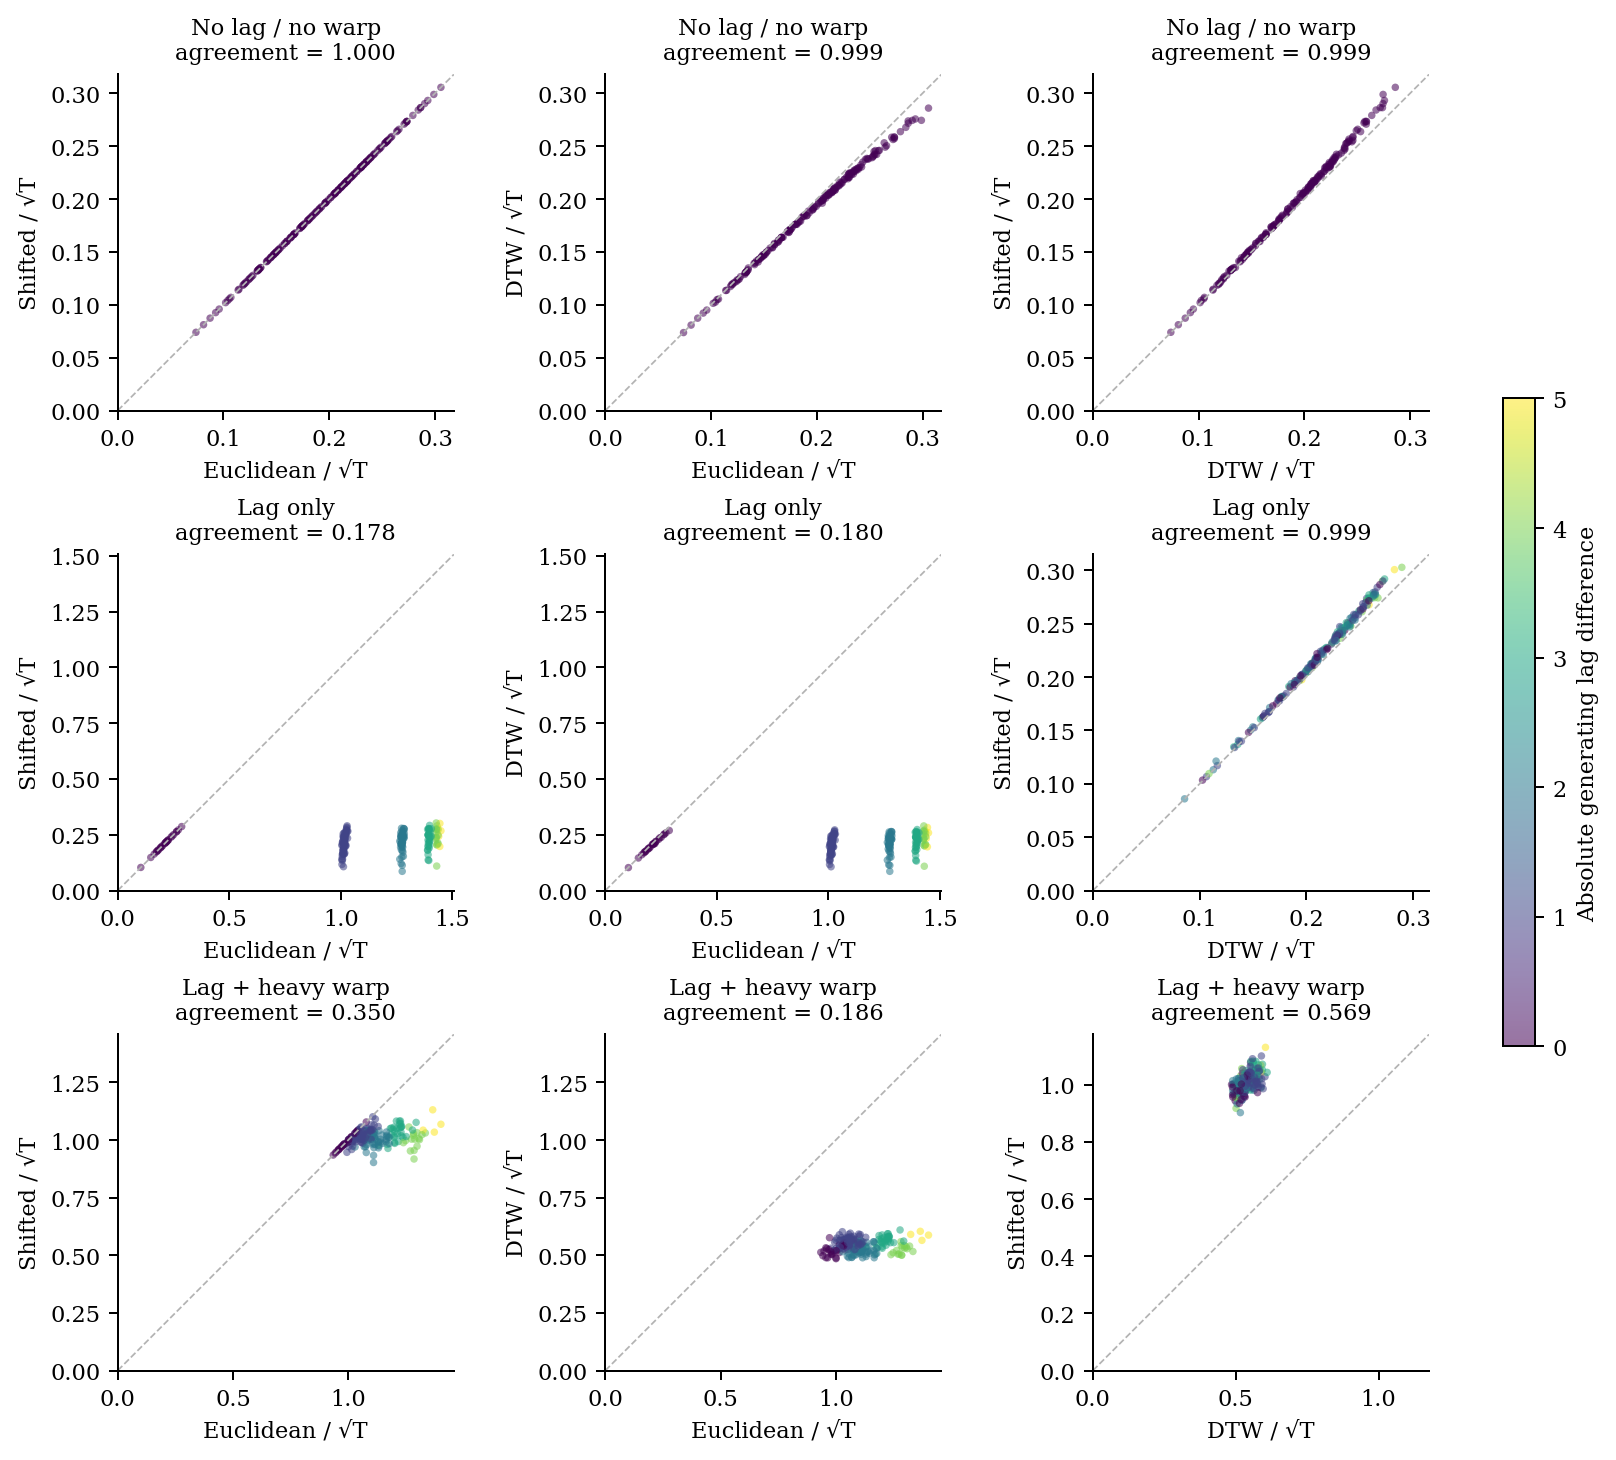

In [3]:
fig = plot_spi_planes(frame, 'dtw', OUT)
plt.show()

Averaging warp offsets across channels does not guarantee exact lag recovery for individual pairs. The optimal global shift can differ from the generating lag even without noise. Correlation between distance matrices describes agreement across pairs; it is not an alignment-accuracy score.

Generation and analysis choices are recorded in `configs/analysis/proof-cases-refresh-260924.yaml`. The helpers save SVG figures and PNG previews under the result directory. Earlier notebooks and result banks are preserved.